In [1]:
import anndata
import numpy as np
from scipy import sparse
import os
import numpy as np
import scanpy as sc
import decoupler as dc
import os
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gseapy as gp

In [2]:
metadata = pd.read_csv(os.path.expanduser("~/Downloads/metadatapdac.csv"), index_col=0)
path = os.path.expanduser('~/Downloads/normalized_data_with_hvg_pca_umap_phenotypes_finalV12.h5ad')
adata = sc.read_h5ad(path)

In [3]:
adata_filt = adata = adata[adata.obs.index.isin(metadata.index)]

# add metadata
adata_filt.obs = adata_filt.obs.join(metadata)

In [ ]:
(adata.obs['mito_frac'] > 30).sum()
adata_filt = adata_filt[adata_filt.obs["cluster"] != "Type B"]

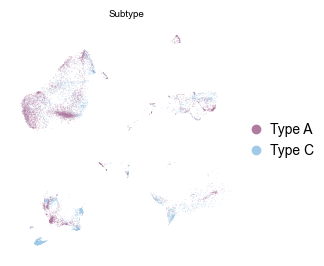

In [27]:
downloads_path = os.path.expanduser("~/Downloads")
sc.settings.figdir = downloads_path
sc.settings.dpi = 300
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6  
plt.rcParams['axes.titlesize'] = 7  
plt.rcParams['pdf.fonttype'] = 42 

sc.pl.umap(adata_filt, color='cluster',
           size=0.5,   
            palette={'Type A': '#B07AA1FF', 'Type C': '#A0CBE8FF'},       
    alpha=0.8,         
    frameon=False, 
    title = "Subtype",
    save="pdac_subtype.pdf")

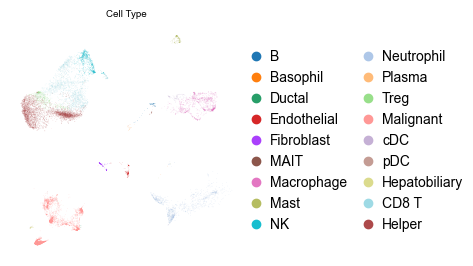

In [28]:
plt.rcParams['figure.figsize'] = (3, 3)

sc.pl.umap(adata_filt, color='auto_cell_type_V9',
           size=0.5,   
                   
    alpha=0.5,         
    frameon=False, 
    title = "Cell Type",
    save="pdac_celltype.pdf")

plt.close()

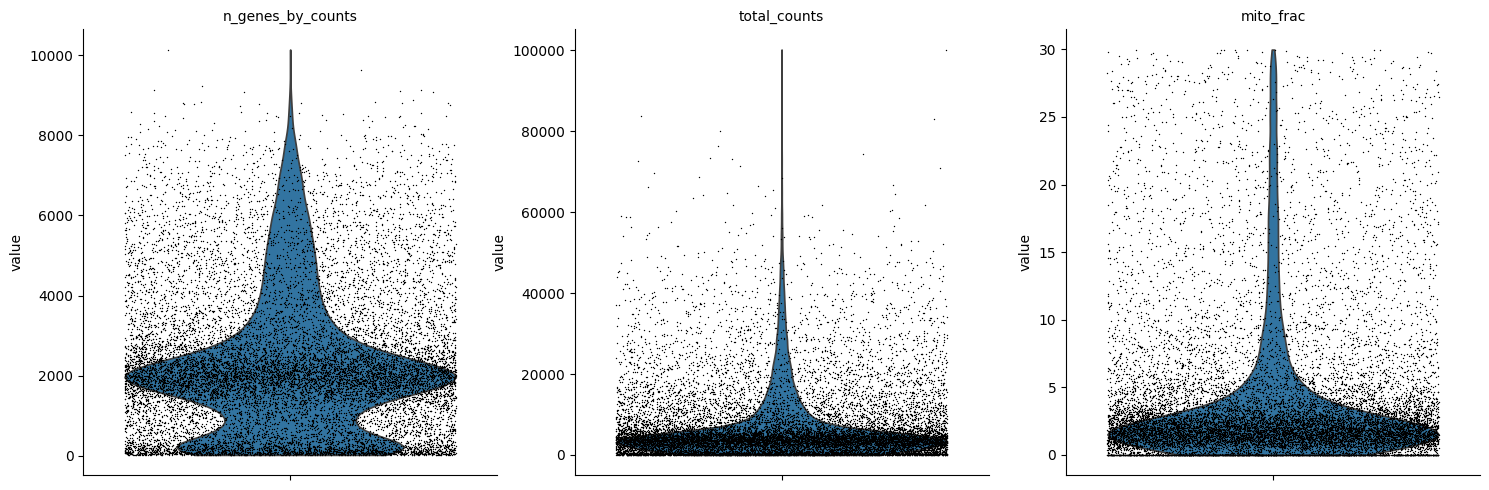

In [ ]:
sc.pl.violin(
    adata_filt,
    ["n_genes_by_counts", "total_counts", "mito_frac"],
    jitter=0.4,
    multi_panel=True)

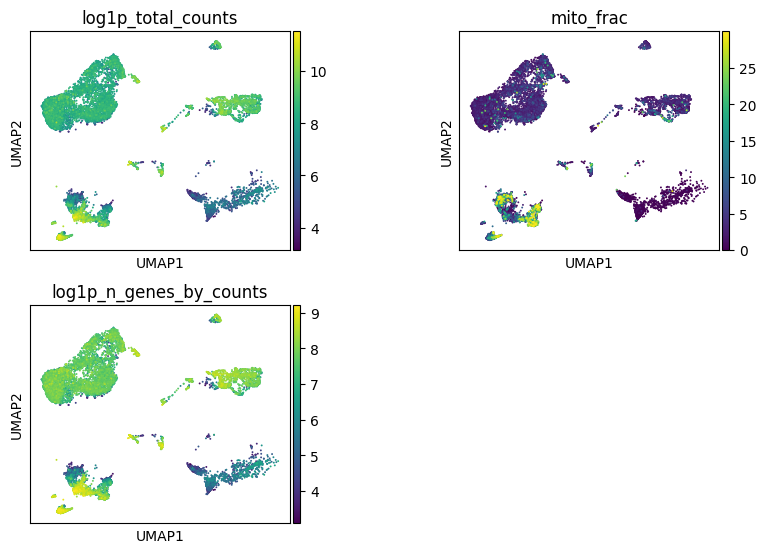

In [ ]:
# data was already qced but making sure it looks good
sc.pl.umap(
    adata_filt,
    color=["log1p_total_counts", "mito_frac", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

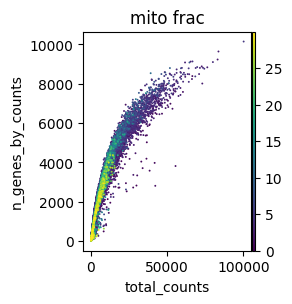

In [9]:
sc.pl.scatter(adata_filt, "total_counts", "n_genes_by_counts", color="mito_frac")

In [5]:
pdata = dc.pp.pseudobulk(
    adata_filt,
    sample_col="sample_ID",
    groups_col="auto_cell_type_V9",
    layer="raw",     
    mode="sum"
)

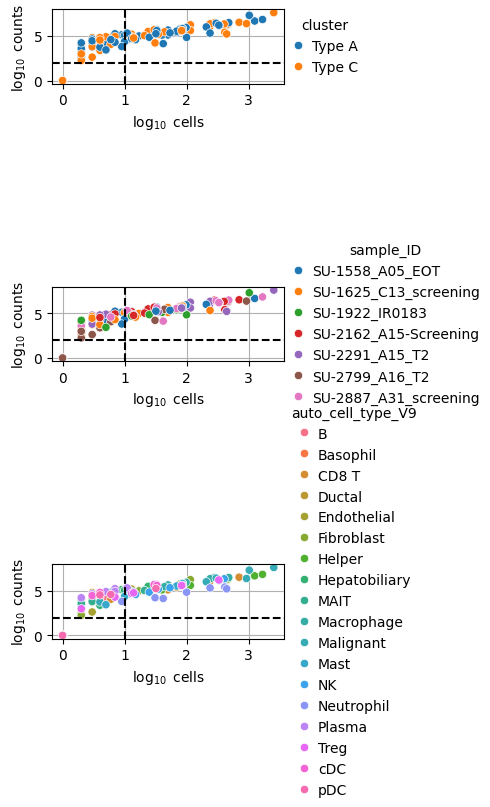

In [6]:

dc.pl.filter_samples(
    adata=pdata,
    groupby=["cluster", "sample_ID", "auto_cell_type_V9"],  
    min_cells = 10, 
    min_counts = 100,
    figsize=(5, 8),
)

In [ ]:
#ensure enough cells 
pdata.obs['cluster'].value_counts()

cluster
Type A    72
Type C    54
Name: count, dtype: int64

In [8]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=100)

In [9]:


results = {}

outdir = "./results_degs_dropped_sample/"
os.makedirs(outdir, exist_ok=True)

for celltype in pdata.obs["auto_cell_type_V9"].unique():

    print(f"\nRunning DESeq2 for cell type: {celltype}")

    adata_sub = pdata[pdata.obs["auto_cell_type_V9"] == celltype].copy()

    counts = adata_sub.obs["cluster"].value_counts()
    n_clusters = adata_sub.obs["cluster"].unique()

    print(counts)
    if("Type A" not in n_clusters or counts["Type A"] < 2 or counts["Type C"] < 2): 
        continue
   
    dds = DeseqDataSet(
        adata=adata_sub,
        design="~ cluster",
        refit_cooks=True
    )

    dds.deseq2()
    results[celltype] = {}
    
    stat_CA = DeseqStats(
        dds,
        contrast=["cluster", "Type A", "Type C"]
    )
    stat_CA.summary()
    results[celltype]["C_vs_A"] = stat_CA.results_df

    for name, df in results[celltype].items():
        df.to_csv(os.path.join(outdir, f"{celltype}_{name}.csv"))


Running DESeq2 for cell type: B
cluster
Type A    1
Type C    1
Name: count, dtype: int64

Running DESeq2 for cell type: CD8 T
cluster
Type A    4
Type C    2
Name: count, dtype: int64
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.71 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.68 seconds.

Fitting LFCs...
... done in 0.73 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.51 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: cluster Type A vs Type C
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                    
A1BG        53.127138        0.005507  0.549298  0.010026  0.992000  0.999931
A1BG-AS1     6.469210       -0.797281  0.999323 -0.797821  0.424974  0.999931
A1CF         0.000000             NaN       NaN       NaN       NaN       NaN
A2M         32.176634        0.571447  0.586832  0.973782  0.330165  0.999931
A2M-AS1      7.059859       -0.142984  1.084988 -0.131784  0.895155  0.999931
...               ...             ...       ...       ...       ...       ...
ZYG11A       0.047857        0.487863  4.597224  0.106121  0.915486  0.999931
ZYG11B       5.745345       -0.521190  1.028045 -0.506972  0.612175  0.999931
ZYX        197.656341       -0.172843  0.486812 -0.355051  0.722552  0.999931
ZZEF1       43.231549       -0.033645  0.511128 -0.065825  0.947517  0.999931
Z

Fitting dispersions...
... done in 0.73 seconds.

Fitting dispersion trend curve...
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 1.48 seconds.

Fitting LFCs...
... done in 1.28 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.57 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: cluster Type A vs Type C
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                    
A1BG        52.681452        0.383005  0.471337  0.812593  0.416451  0.999976
A1BG-AS1     9.996993        0.619742  0.929952  0.666423  0.505141  0.999976
A1CF         0.031801        0.515388  2.790696  0.184681  0.853479  0.999976
A2M         13.745638        0.828713  0.854899  0.969369  0.332361  0.999976
A2M-AS1      1.932128        0.933850  1.260022  0.741137  0.458610  0.999976
...               ...             ...       ...       ...       ...       ...
ZYG11A       0.519919       -1.997226  1.784090 -1.119465  0.262942  0.999976
ZYG11B      15.221104       -0.278604  0.751916 -0.370525  0.710991  0.999976
ZYX        191.122453       -0.234326  0.760252 -0.308222  0.757914  0.999976
ZZEF1       54.010584       -0.219766  0.773452 -0.284136  0.776306  0.999976
Z

...

Fitting dispersions...
... done in 0.49 seconds.

Fitting dispersion trend curve...
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 0.65 seconds.

Fitting LFCs...
... done in 0.71 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.50 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: cluster Type A vs Type C
            baseMean  log2FoldChange     lfcSE      stat    pvalue     padj
gene_name                                                                  
A1BG        0.252962        0.681840  2.984980  0.228424  0.819317  0.99936
A1BG-AS1    0.000000             NaN       NaN       NaN       NaN      NaN
A1CF        0.000000             NaN       NaN       NaN       NaN      NaN
A2M         0.701893       -1.446549  4.406510 -0.328275  0.742703  0.99936
A2M-AS1     0.000000             NaN       NaN       NaN       NaN      NaN
...              ...             ...       ...       ...       ...      ...
ZYG11A      0.000000             NaN       NaN       NaN       NaN      NaN
ZYG11B      3.097426       -1.040879  1.317253 -0.790189  0.429418  0.99936
ZYX        17.653890        0.304727  0.898935  0.338987  0.734620  0.99936
ZZEF1       5.329435       -0.137917  1.072025 -0.128651  0.897634  0.99936
ZZZ3        0.463704     

Fitting dispersions...
... done in 0.54 seconds.

Fitting dispersion trend curve...
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.12 seconds.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.66 seconds.

Fitting LFCs...
... done in 0.67 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: cluster Type A vs Type C
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                   
A1BG       11.156446        0.434571  1.154029  0.376568  0.706494  0.999883
A1BG-AS1    2.169101       -0.799047  1.580122 -0.505687  0.613076  0.999883
A1CF        0.000000             NaN       NaN       NaN       NaN       NaN
A2M         0.584285       -0.415128  1.902710 -0.218177  0.827291  0.999883
A2M-AS1     0.233412       -0.656292  2.313048 -0.283735  0.776614  0.999883
...              ...             ...       ...       ...       ...       ...
ZYG11A      0.168543        0.649025  2.678488  0.242310  0.808540  0.999883
ZYG11B      2.223382        0.255555  1.605901  0.159135  0.873562  0.999883
ZYX        54.238264       -0.184522  1.026935 -0.179682  0.857402  0.999883
ZZEF1      11.857854        0.714416  1.243036  0.574735  0.565471  0.999883
ZZZ3       10

... done in 0.49 seconds.



In [10]:
gene_sets = gp.read_gmt("/Users/boscens/Desktop/reznik/bodycomp_main/data/reference/h.all.v2025.1.Hs.symbols.gmt")

In [16]:
def run_gsea_for_all(results, gene_sets):

    all_results = []

    for ct, ct_res in results.items():
        print(f"Running GSEA for: {ct}")

        for comp, df in ct_res.items():

            ranks = df["stat"].copy()
            ranks.index = df.index
            ranks = ranks.dropna().sort_values(ascending=False)
            print(ranks.head())

            pre = gp.prerank(
                rnk=ranks,
                gene_sets=gene_sets,
                permutation_num=60000,
                seed=42,
                outdir=None,
                no_plot=True
            )

            res = pre.res2d.copy()

            res["cell_type"] = ct
            res["comparison"] = comp
            res["pathway"] = res.index

            all_results.append(res.reset_index(drop=True))

    final_df = pd.concat(all_results, ignore_index=True)

    return final_df

In [17]:
gsea_results = run_gsea_for_all(results, gene_sets)
gsea_results.to_csv("./gsea_all_results_pdac_dropped_sample_0423.csv", index=False)

2026-04-28 10:00:21,647 [WARNING] Duplicated values found in preranked stats: 21.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for: CD8 T
gene_name
PTPRCAP      5.523327
TRBV6-5      3.991673
HLA-DRB5     3.787293
LINC00486    3.720484
SMN2         3.613305
Name: stat, dtype: float64


2026-04-28 10:04:06,397 [WARNING] Duplicated values found in preranked stats: 21.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for: Helper
gene_name
PTPRCAP    3.658297
PLCG2      2.954305
SLCO5A1    2.770767
ERAP2      2.697476
TRAV1-1    2.550863
Name: stat, dtype: float64


2026-04-28 10:06:52,615 [WARNING] Duplicated values found in preranked stats: 17.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

Running GSEA for: NK
gene_name
HLA-DRB5     3.299481
PTPRCAP      2.837202
NME4         2.463270
CFLAR-AS1    2.423194
SYNGR1       2.372886
Name: stat, dtype: float64


2026-04-28 10:17:38,709 [WARNING] Duplicated values found in preranked stats: 51.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for: Neutrophil
gene_name
CCL4L2     2.912212
CCL3L3     2.806061
CARD16     2.458429
MIR22HG    2.425591
C1GALT1    2.176622
Name: stat, dtype: float64


2026-04-28 10:18:32,234 [WARNING] Duplicated values found in preranked stats: 31.96% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA for: Treg
gene_name
PTPRCAP    2.409820
TRBV7-7    2.264793
HBB        2.188301
TRAV21     2.120036
DDX52      2.070332
Name: stat, dtype: float64
